In [1]:
import numpy as np
import h5py
from codes.utils import *
import matplotlib.pyplot as plt

1. Data preparation

In [2]:
# Load fundamental-model R-wave dispersion data
# dc_file_location = 'E:/writing paper/A unified Framework/test/m1/dispersion.txt'
# file_data = np.loadtxt(dc_file_location)
# f = file_data[:,0]
# vr = file_data[:,1]

file_data = h5py.File('E:/writing paper/A unified Framework/test/s1/s1.mat', 'r')
f = file_data['f'][:].T.reshape(-1)
vr = file_data['vr'][:].T.reshape(-1)

# Sort the dispersion data from smallest to largest frequency
sorted_indices = np.argsort(f)
f = f[sorted_indices]
vr = vr[sorted_indices]

2. Dispersion curve normalization

In [3]:
# Estimate halfspace depth and S-wave velocity bounds
vr_max = np.max(vr)
wavelength_max = np.max(vr / f)
vs_bounds_halfspace =  np.array([1.0723562676808107, 2.2]) * vr_max 
depth_bounds_halfspace = np.array([1/3, 1]) * wavelength_max

# Normalization and resampling with parallel processing
depth_scalers, vs_scalers, f_matrix, vr_matrix = scale_dc(f, vr, vs_bounds_halfspace, depth_bounds_halfspace)
f_vr_sampled = resample_parallel(f_matrix, vr_matrix, n_jobs=-1)
f_vr_sampled = np.array(f_vr_sampled, dtype=object)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 390 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 23040 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 112640 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done 160000 out of 160000 | elapsed:   12.1s finished


3. Inversion

In [ ]:
model_path = r"E:\writing paper\A unified Framework\test2\model\20%_layernorm_sum_aggregation_loss.pth"  # model path
scaler_path = r"E:\writing paper\A unified Framework\test2\model\20%_layernorm_sum_aggregation_scaler.pkl"  # scaler path
vs_predict = run_prediction(model_path, scaler_path, f_vr_sampled)

Using device: cuda
Input data: 160000 samples
Loading scalers...


d:\anaconda3\envs\DC\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loading model...
Model parameters: 2,115,204
Preprocessing data...
Starting prediction...


Prediction Progress: 100%|██████████| 160000/160000 [00:12<00:00, 12481.71it/s]


Prediction complete!
Final result shape: (160000, 100)


4. Denormalization

In [5]:
# Each row of thickness_inverted and vs_predict corresponds to a predicted S-wave velocity profile
# The last column of thickness_inverted is the thickness of the halfspace, the values do not matter
thickness_inverted, vs_inverted = denormalize_dc(vs_predict, depth_scalers, vs_scalers)

5. Forward computation

In [ ]:
vr_inverted = forward_parallel(thickness_inverted, vs_inverted, f, n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 4000 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 9600 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 16800 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-1)]: Done 25600 tasks      | elapsed:   17.6s
[Parallel(n_jobs=-1)]: Done 36000 tasks      | elapsed:   24.1s
[Parallel(n_jobs=-1)]: Done 48000 tasks      | elapsed:   31.9s
[Parallel(n_jobs=-1)]: Done 61600 tasks      | elapsed:   41.0s
[Parallel(n_jobs=-1)]: Done 76800 tasks      | elapsed:   50.9s
[Parallel(n_jobs=-1)]: Done 93600 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 112000 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 132000 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 153600 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 16

6. Evalualte

In [7]:
# Set an error tolerance 
vr_err = 0.05 * vr

qualified_indices = find_qualified_indices_and_rank(vr, vr_err, vr_inverted)
print(f"Number of qualified models: {len(qualified_indices)}")
thickness_qualified = thickness_inverted[qualified_indices]
vs_qualified = vs_inverted[qualified_indices]
vr_qualified = vr_inverted[qualified_indices]

Number of qualified models: 69452


7. Plot

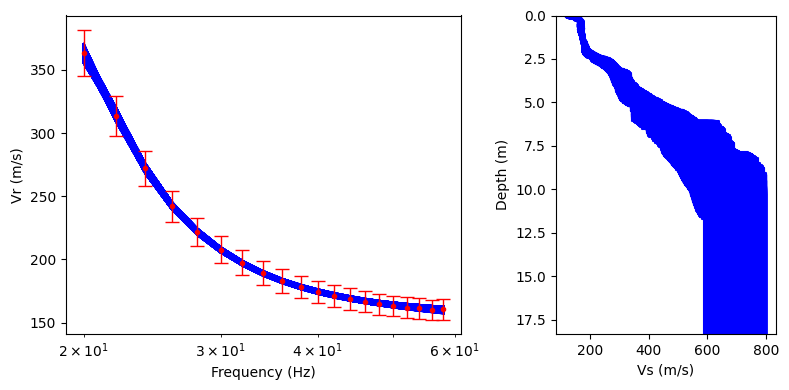

In [8]:
plot_number = 10000

fig, axs = plt.subplots(1, 2, 
                        figsize=(8, 4), 
                        gridspec_kw={'width_ratios': [1.8, 1]})

for i in range(plot_number):
    axs[0].plot(f, vr_qualified[i], 'b-')
axs[0].errorbar(f,vr, yerr=vr_err.reshape(-1), fmt='o', ecolor='red', elinewidth=1, markersize=3,capsize=5,color = 'red')
axs[0].set_xscale('log')
axs[0].set_xlabel('Frequency (Hz)')
axs[0].set_ylabel('Vr (m/s)')

depth_plot = get_depth_for_plot(thickness_qualified)
vs_plot = np.repeat(vs_qualified,2,axis=1)
for i in range(plot_number):
    axs[1].plot(vs_plot[i],depth_plot[i],color = 'blue')
axs[1].set_ylim(0, np.max(depth_plot))
axs[1].set_xlabel('Vs (m/s)')
axs[1].set_ylabel('Depth (m)')
axs[1].invert_yaxis()
plt.tight_layout()